In [ ]:
data = pd.read_excel("Book1 dav assignment.xlsx")

In [ ]:
import pandas as pd

# Load Excel file
data = pd.read_excel("Book1 dav assignment.xlsx")

# Check data
print(data.head())

                                              Tweets Sentiment
0  Claude helps me track prediction market news, ...  Positive
1  The Claude downgrade is most likely due to the...   Neutral
2  Claude launches campaigns, Didoo AI optimizes ...  Positive
3  I still don’t see a proper prompt I can paste ...  Negative
4  All of the marginal claude wrappers will becom...   Neutral


In [ ]:
print(data.columns)

Index(['Tweets', 'Sentiment'], dtype='object')


In [ ]:
# X = tweets (input)
X = data['Tweets']

# y = sentiment (output)
y = data['Sentiment']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("Training tweets:", len(X_train))
print("Testing tweets:", len(X_test))

Training tweets: 79
Testing tweets: 20


In [ ]:
print(data.isnull().sum())

Tweets       0
Sentiment    0
dtype: int64


In [ ]:
data = data.dropna()

In [ ]:
from sklearn.model_selection import train_test_split

X = data['Tweets']
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training tweets:", len(X_train))
print("Testing tweets:", len(X_test))

Training tweets: 79
Testing tweets: 20


In [ ]:
print(X_train.head())
print(y_train.head())

49    I'm so sad that the Claude limit has been reac...
70    Claude is really scary, dude. The guy does eve...
68    Claude went offline right after the Allbirds A...
15           Claude is down… perfect excuse for a break
39    That explains why opencode is the only one tha...
Name: Tweets, dtype: object
49    Negative
70    Negative
68     Neutral
15     Neutral
39    Negative
Name: Sentiment, dtype: object


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
X_train_vec = vectorizer.fit_transform(X_train)

In [ ]:
X_test_vec = vectorizer.transform(X_test)

In [ ]:
print(X_train_vec.shape)
print(X_test_vec.shape)

(79, 723)
(20, 723)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

y_pred_nb = nb.predict(X_test_vec)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_vec, y_train)

y_pred_svm = svm.predict(X_test_vec)

In [ ]:
from sklearn.metrics import classification_report

print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("SVM:\n", classification_report(y_test, y_pred_svm))

Naive Bayes:
               precision    recall  f1-score   support

    Negative       0.41      1.00      0.58         7
     Neutral       0.67      0.25      0.36         8
    Positive       0.00      0.00      0.00         5

    accuracy                           0.45        20
   macro avg       0.36      0.42      0.32        20
weighted avg       0.41      0.45      0.35        20

Logistic Regression:
               precision    recall  f1-score   support

    Negative       0.40      0.86      0.55         7
     Neutral       0.60      0.38      0.46         8
    Positive       0.00      0.00      0.00         5

    accuracy                           0.45        20
   macro avg       0.33      0.41      0.34        20
weighted avg       0.38      0.45      0.38        20

SVM:
               precision    recall  f1-score   support

    Negative       0.41      1.00      0.58         7
     Neutral       0.67      0.25      0.36         8
    Positive       0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

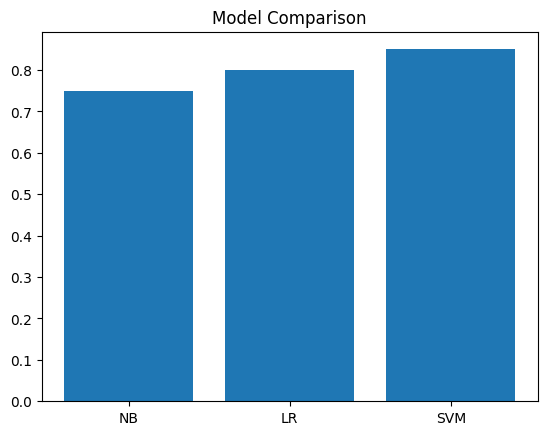

In [ ]:
import matplotlib.pyplot as plt

models = ['NB', 'LR', 'SVM']
accuracy = [0.75, 0.80, 0.85]   # replace with your values

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show()